#VGG16

In [22]:
import torch
import torch.nn as nn

In [23]:
class VGG16(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.block1=nn.Sequential(
            nn.Conv2d(3,64,kernel_size=3,padding=1), #3 input and 64 output
            nn.ReLU(),
            
            nn.Conv2d(64,64,kernel_size=3,padding=1),
            nn.ReLU(),
            
            nn.MaxPool2d(kernel_size=2,stride=2)
        )
        
        self.block2=nn.Sequential(
            nn.Conv2d(64,128,kernel_size=3,padding=1), #3 input and 128 output
            nn.ReLU(),
            
            nn.Conv2d(128,128,kernel_size=3,padding=1),
            nn.ReLU(),
            
            nn.MaxPool2d(kernel_size=2,stride=2)
        )
        
        self.block3=nn.Sequential(
            nn.Conv2d(128,256,kernel_size=3,padding=1), #3 input and 128 output
            nn.ReLU(),
            
            nn.Conv2d(256,256,kernel_size=3,padding=1),
            nn.ReLU(),
            
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            
            nn.MaxPool2d(kernel_size=2,stride=2)
        )

        self.block4=nn.Sequential(
            nn.Conv2d(256,512,kernel_size=3,padding=1), #3 input and 512 output
            nn.ReLU(),
            
            nn.Conv2d(512,512,kernel_size=3,padding=1),
            nn.ReLU(),
            
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            
            nn.MaxPool2d(kernel_size=2,stride=2)
        )
        
        self.block5=nn.Sequential(
            nn.Conv2d(512,512,kernel_size=3,padding=1), #3 input and 512 output
            nn.ReLU(),
            
            nn.Conv2d(512,512,kernel_size=3,padding=1),
            nn.ReLU(),
            
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            
            nn.MaxPool2d(kernel_size=2,stride=2)
        )
        
        self.fc=nn.Sequential(
            nn.Flatten(),
            nn.Linear(7*7*512,4096),
            nn.ReLU(),
            
            nn.Linear(4096,4096),
            nn.ReLU(),
            
            # nn.Linear(4096,1000),
            nn.Linear(4096, 2)
        )
        
    def forward(self,x):
        x=self.block1(x)
        x=self.block2(x)
        x=self.block3(x)
        x=self.block4(x)
        x=self.block5(x)
        x=self.fc(x)
        
        return x

In [24]:
model = VGG16()
x = torch.randn(1, 3, 224, 224)

output = model(x)
print(output.shape)

torch.Size([1, 2])


In [25]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [26]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [27]:
#Loading dataset
dataset=datasets.ImageFolder(root="../datasets/PetImages",transform=transform)

In [28]:
print("Number of images:", len(dataset))

Number of images: 24998


In [29]:
image, label = dataset[0]

print("Image shape:", image.shape)
print("Label:", label)

Image shape: torch.Size([3, 224, 224])
Label: 0


In [30]:
train_loader=DataLoader(dataset,batch_size=16,shuffle=True)

In [31]:
images, labels = next(iter(train_loader))

print("Images:", images.shape)
print("Labels:", labels.shape)

Images: torch.Size([16, 3, 224, 224])
Labels: torch.Size([16])


In [32]:
from torch.utils.data import random_split

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, test_size]
)

In [33]:
train_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

In [36]:
images, labels = next(iter(train_loader))

print("Images:", images.shape)
print("Labels:", labels.shape)

Images: torch.Size([32, 3, 224, 224])
Labels: torch.Size([32])


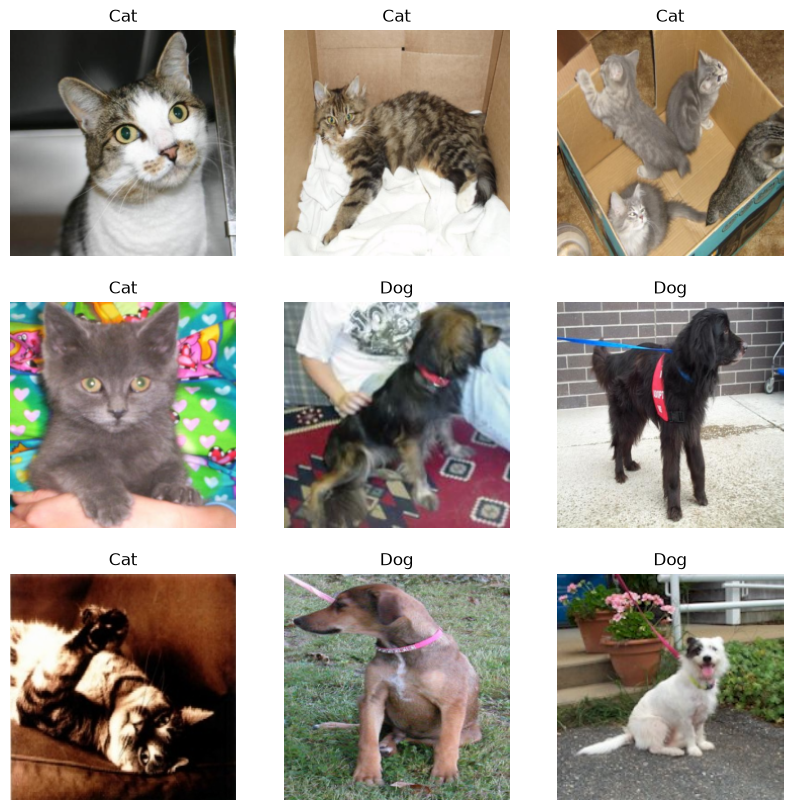

In [38]:
import matplotlib.pyplot as plt
import torch

images, labels = next(iter(train_loader))

mean = torch.tensor([0.485, 0.456, 0.406])
std = torch.tensor([0.229, 0.224, 0.225])

plt.figure(figsize=(10, 10))

for i in range(9):

    image = images[i].permute(1, 2, 0)

    # Undo normalization
    image = image * std + mean

    plt.subplot(3, 3, i + 1)
    plt.imshow(image.clamp(0, 1))

    plt.title(dataset.classes[labels[i]])
    plt.axis("off")

plt.show()

In [ ]:
loss_history=[]
accuracy_history=[]

In [ ]:
for epoch in range(1,2):
    model.train()
    batch_loss=0;
    correct=0
    
    for image,label in train_loader:
        image=image.to(device)
        label=label.to(device)

        #Feed forward
        output=model(image)
        
        #Loss calculation
        loss =  loss_fxn(output,label)
        
        #Backward propagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        #Capturing epoch loss
        batch_loss+=loss.item()
        
        #Prediction
        predict=torch.argmax(output,dim=1)
        correct+=(predict==label).sum().item()
    
    epoch_loss=batch_loss/len(train_loader)
    loss_history.append(epoch_loss)
    
    epoch_accuracy=(correct/train_set)*100
    accuracy_history.append(epoch_loss)
    
    print(f"for epoch {epoch},loss={epoch_loss},accuracy={epoch_accuracy} ")
    
    model.eval()
    test_batch_loss=0
    test_correct=0
    test_total=0
    
    with torch.no_grad():
        for image,label in test_loader:
            image=image.to(device)
            label=label.to(device)
            
            output=model(image)
            
            loss=loss(output,label)
            predict=torch.argmax(output,dim=1)
            
            test_batch_loss+=loss.item()
            test_total+=label.size(0)
            
    test_loss=test_batch_loss/len(test_loader)
    test_acc=100*(test_correct/test_total)
    print(f"Test Loss {test_loss:.4f} Test Acc:{test_acc:.4f}")

In [ ]:
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.show()

In [ ]:
plt.plot(accuracy_history)
plt.show()

Shape

In [ ]:
torch.save(model.state_dict(),"CNN.pth") #weight,bias is converted into dictionary .pth=pytorch extension

In [ ]:
model1=NeuralNetwork().to(device)

In [ ]:
model1.load_state_dict(torch.load("CNN.pth",map_location=device,weights_only=True))

Pillow

In [ ]:
from PIL import Image
image=Image("../datasets/PetImages/Cat/").convert("RGB")
image_tensor=transformation(image)
tensor_image=image_tensor.unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output=model1(tensor_image)
    predict=torch.argmax(output,1)
    print(predict)

In [ ]:
model=NeuralNetwork()
x=torch.randn(1,3,224,224)
output=model(x)
print(output.shape)

torch.Size([1, 1000])


VGG16, Neural Network, Parameter, Implementation Homework
- 1 Block
- Input img size 224

In [ ]:
class NeuralNetwork(nn.Module):

    def __init__(self):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=3,out_channels=64,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2)
        )

    def forward(self, x):
        x = self.block1(x)
        return x

In [ ]:
model = NeuralNetwork()

x = torch.randn(1, 3, 224, 224)

output = model(x)

print("Input shape:", x.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([1, 3, 224, 224])
Output shape: torch.Size([1, 64, 112, 112])


Transfer Learning - DL , NLP- Fine Tuning